In [1]:
%cd /content

!git clone https://github.com/ContemporaryCat/Manga-Text-Segmentation.git

!ls -lah /content/Manga-Text-Segmentation

/content
fatal: destination path 'Manga-Text-Segmentation' already exists and is not an empty directory.
total 207M
drwxr-xr-x 4 root root 4.0K Sep 13 12:51 .
drwxr-xr-x 1 root root 4.0K Sep 13 12:52 ..
drwxr-xr-x 3 root root 4.0K Sep 13 12:51 .cache
drwxr-xr-x 8 root root 4.0K Sep 13 12:49 .git
-rw-r--r-- 1 root root  12K Sep 13 12:49 inference.py
-rw-r--r-- 1 root root 207M Sep 13 12:51 model.pth
-rw-r--r-- 1 root root 2.4K Sep 13 12:49 README.md


In [2]:
!pip install -q segmentation-models-pytorch albumentations opencv-python gradio timm

!pip install -q huggingface_hub

In [3]:
import torch
import segmentation_models_pytorch as smp
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ENCODER = "tu-efficientnetv2_rw_m"

model = smp.UnetPlusPlus(
    encoder_name=ENCODER,
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
    decoder_attention_type="scse"
)

print(model.__class__.__name__)
print("Device:", DEVICE)

UnetPlusPlus
Device: cuda


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

print("[*] Đang giải nén ảnh gốc vào /content/data/raw...")

os.makedirs("/content/data/raw", exist_ok=True)

!unzip -q -o "/content/drive/MyDrive/DIP/data/raw/Manga109s_released_2026_05_21-001.zip" \
    -d "/content/data/raw/"

print("[*] Đang giải nén ground-truth vào /content/data/groundtruth...")

os.makedirs("/content/data/groundtruth", exist_ok=True)

!unzip -q -o "/content/drive/MyDrive/DIP/data/groundtruth/post-processed.zip" \
    -d "/content/data/groundtruth/"

print("✅ Đã giải nén xong!")

[*] Đang giải nén ảnh gốc vào /content/data/raw...
[*] Đang giải nén ground-truth vào /content/data/groundtruth...
✅ Đã giải nén xong!


In [6]:
RAW_DIR = "/content/data/raw/Manga109s_released_2026_05_21/images"
GT_DIR = "/content/data/groundtruth/post-processed"

print("RAW_DIR =", RAW_DIR)
print("GT_DIR  =", GT_DIR)

RAW_DIR = /content/data/raw/Manga109s_released_2026_05_21/images
GT_DIR  = /content/data/groundtruth/post-processed


In [7]:
%cd /content/Manga-Text-Segmentation

print("=== Git commit ===")
!git rev-parse HEAD

print("\n=== Files ===")
!ls -lah

/content/Manga-Text-Segmentation
=== Git commit ===
6cfa907b0721faa398054be527de98171746ef1b

=== Files ===
total 207M
drwxr-xr-x 4 root root 4.0K Sep 13 12:51 .
drwxr-xr-x 1 root root 4.0K Sep 13 12:52 ..
drwxr-xr-x 3 root root 4.0K Sep 13 12:51 .cache
drwxr-xr-x 8 root root 4.0K Sep 13 12:49 .git
-rw-r--r-- 1 root root  12K Sep 13 12:49 inference.py
-rw-r--r-- 1 root root 207M Sep 13 12:51 model.pth
-rw-r--r-- 1 root root 2.4K Sep 13 12:49 README.md


In [8]:
from huggingface_hub import hf_hub_download
import os

MODEL_DIR = "/content/Manga-Text-Segmentation"
MODEL_PATH = os.path.join(MODEL_DIR, "model.pth")

model_path = hf_hub_download(
    repo_id="a-b-c-x-y-z/Manga-Text-Segmentation-2025",
    filename="model.pth",
    local_dir=MODEL_DIR
)

print("✅ Model downloaded:")
print(model_path)
print("Size:", round(os.path.getsize(model_path) / (1024**2), 2), "MB")

✅ Model downloaded:
/content/Manga-Text-Segmentation/model.pth
Size: 206.86 MB


In [9]:
import os
import torch
import segmentation_models_pytorch as smp
import torch.nn as nn

MODEL_PATH = "/content/Manga-Text-Segmentation/model.pth"

# Kiểm tra model
print("Model exists:", os.path.exists(MODEL_PATH))
print("Model size:", round(os.path.getsize(MODEL_PATH) / (1024**2), 2), "MB")

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# =========================
# Convert BatchNorm -> GroupNorm
# =========================
def convert_batchnorm_to_groupnorm(module, num_groups=8):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            num_channels = child.num_features

            # Chọn số group phù hợp với số channel
            groups = min(num_groups, num_channels)

            while num_channels % groups != 0 and groups > 1:
                groups -= 1

            setattr(
                module,
                name,
                nn.GroupNorm(
                    num_groups=groups,
                    num_channels=num_channels
                )
            )
        else:
            convert_batchnorm_to_groupnorm(child, num_groups)


# =========================
# Create model
# =========================
ENCODER = "tu-efficientnetv2_rw_m"

print("\n[*] Creating UNet++ model...")

model = smp.UnetPlusPlus(
    encoder_name=ENCODER,
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
    decoder_attention_type="scse"
)

print("[*] Converting BatchNorm -> GroupNorm...")
convert_batchnorm_to_groupnorm(model.decoder)

print("[*] Loading model.pth...")

state_dict = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(state_dict)

model = model.to(DEVICE)
model.eval()

print("\n✅ Model loaded successfully!")
print("Architecture:", type(model).__name__)
print("Encoder:", ENCODER)
print("Device:", DEVICE)

Model exists: True
Model size: 206.86 MB
Device: cuda
GPU: Tesla T4

[*] Creating UNet++ model...


[*] Converting BatchNorm -> GroupNorm...
[*] Loading model.pth...

✅ Model loaded successfully!
Architecture: UnetPlusPlus
Encoder: tu-efficientnetv2_rw_m
Device: cuda


In [10]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

RAW_DIR = Path("/content/data/raw/Manga109s_released_2026_05_21/images")
GT_DIR = Path("/content/data/groundtruth/post-processed")

# --------------------------------------------------
# Tìm 1 cặp image / ground-truth có cùng manga + page
# --------------------------------------------------
found_pair = None

for manga_dir in sorted(RAW_DIR.iterdir()):
    if not manga_dir.is_dir():
        continue

    gt_manga_dir = GT_DIR / manga_dir.name

    if not gt_manga_dir.exists():
        continue

    for img_path in sorted(manga_dir.glob("*.jpg")):
        page_id = img_path.stem
        gt_path = gt_manga_dir / f"{page_id}.png"

        if gt_path.exists():
            found_pair = (img_path, gt_path)
            break

    if found_pair:
        break


if found_pair is None:
    raise FileNotFoundError("Không tìm thấy cặp image + ground-truth!")

IMAGE_PATH, GT_PATH = found_pair

print("Image:")
print(IMAGE_PATH)

print("\nGround-truth:")
print(GT_PATH)

Image:
/content/data/raw/Manga109s_released_2026_05_21/images/ARMS/000.jpg

Ground-truth:
/content/data/groundtruth/post-processed/ARMS/000.png


In [11]:
# ============================================
# Official ContemporaryCat preprocessing
# + inference
# ============================================

import cv2
import numpy as np
import torch
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --------------------------------------------------
# Read image
# --------------------------------------------------
image = cv2.imread(str(IMAGE_PATH))

if image is None:
    raise ValueError(f"Không đọc được ảnh: {IMAGE_PATH}")

# OpenCV BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image_rgb.shape[:2]

print("Original image shape:", image_rgb.shape)
print("Original H x W:", h, "x", w)


# --------------------------------------------------
# Official preprocessing
# Normalize FIRST
# --------------------------------------------------
transform = A.Compose([
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

augmented = transform(image=image_rgb)

tensor = augmented["image"].unsqueeze(0).to(DEVICE)

print("Tensor before padding:", tensor.shape)


# --------------------------------------------------
# Padding AFTER normalization
# --------------------------------------------------
pad_h = (32 - h % 32) % 32
pad_w = (32 - w % 32) % 32

if pad_h > 0 or pad_w > 0:
    tensor = F.pad(
        tensor,
        (0, pad_w, 0, pad_h),
        mode="constant",
        value=0
    )

print("Padding H:", pad_h)
print("Padding W:", pad_w)
print("Tensor after padding:", tensor.shape)


# --------------------------------------------------
# Inference
# Official code uses CUDA autocast
# --------------------------------------------------
with torch.no_grad():

    if DEVICE.type == "cuda":
        with torch.amp.autocast("cuda"):
            logits = model(tensor)
            probs = logits.sigmoid()
    else:
        logits = model(tensor)
        probs = logits.sigmoid()


# --------------------------------------------------
# Crop back to original image size
# --------------------------------------------------
prob_map = probs[0, 0, :h, :w].float().cpu().numpy()

print("\n✅ Inference successful!")
print("Probability map:", prob_map.shape)
print("Min probability:", prob_map.min())
print("Max probability:", prob_map.max())
print("Mean probability:", prob_map.mean())


# --------------------------------------------------
# Threshold 0.5
# --------------------------------------------------
pred_mask = (prob_map > 0.5).astype(np.uint8) * 255

print("\nPrediction mask:")
print("Shape:", pred_mask.shape)
print("Dtype:", pred_mask.dtype)
print("Unique values:", np.unique(pred_mask))

Original image shape: (1170, 1654, 3)
Original H x W: 1170 x 1654
Tensor before padding: torch.Size([1, 3, 1170, 1654])
Padding H: 14
Padding W: 10
Tensor after padding: torch.Size([1, 3, 1184, 1664])

✅ Inference successful!
Probability map: (1170, 1654)
Min probability: 1.7881393e-07
Max probability: 1.0
Mean probability: 0.07037655

Prediction mask:
Shape: (1170, 1654)
Dtype: uint8
Unique values: [  0 255]


In [12]:
# ============================================
# Align + normalize Ground Truth
# ============================================

import cv2
import numpy as np

# Đọc GT gốc
gt_original = cv2.imread(
    str(GT_PATH),
    cv2.IMREAD_GRAYSCALE
)

print("Original GT shape:", gt_original.shape)

# --------------------------------------------------
# Crop GT về đúng kích thước raw image
# --------------------------------------------------
gt_aligned = gt_original[:h, :w]

print("Aligned GT shape:", gt_aligned.shape)

# --------------------------------------------------
# Convert:
#   105  -> 255 (TEXT)
#   255  -> 0   (BACKGROUND)
# --------------------------------------------------
gt_binary = np.zeros_like(gt_aligned, dtype=np.uint8)

gt_binary[gt_aligned == 105] = 255

print("\nGT binary:")
print("Shape:", gt_binary.shape)
print("Dtype:", gt_binary.dtype)
print("Unique values:", np.unique(gt_binary))

print(
    "Text pixels:",
    np.count_nonzero(gt_binary == 255)
)

print(
    "Background pixels:",
    np.count_nonzero(gt_binary == 0)
)

Original GT shape: (1176, 1656)
Aligned GT shape: (1170, 1654)

GT binary:
Shape: (1170, 1654)
Dtype: uint8
Unique values: [  0 255]
Text pixels: 116043
Background pixels: 1819137


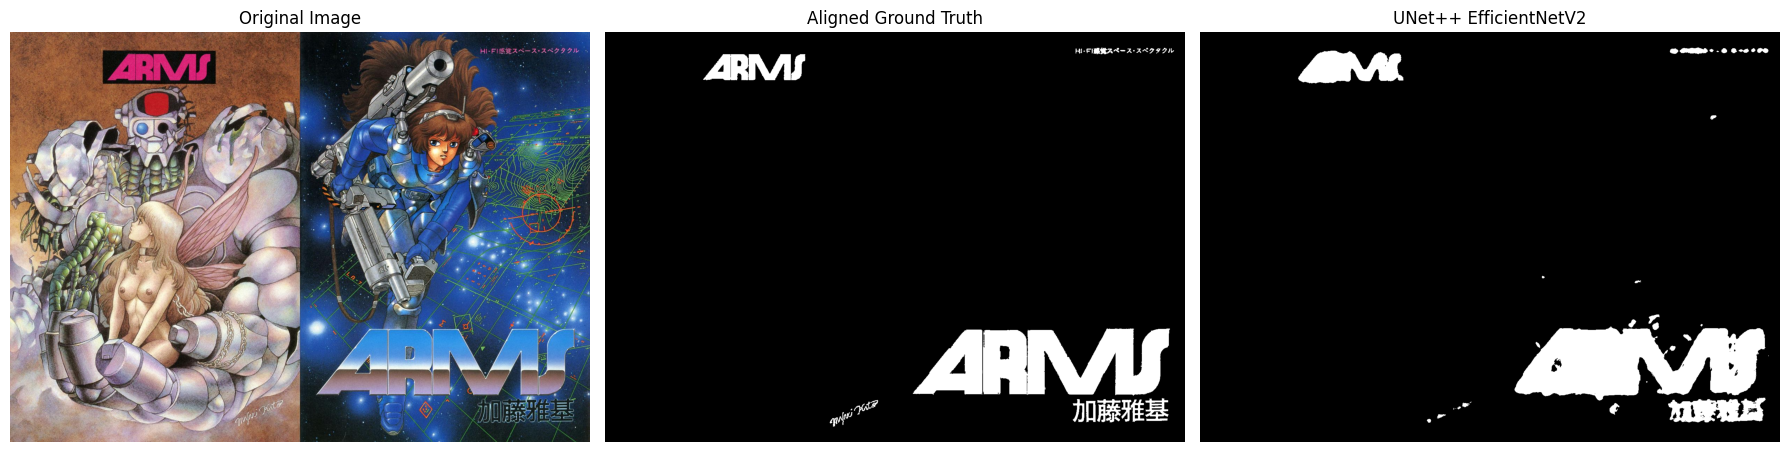

In [13]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_binary, cmap="gray")
plt.title("Aligned Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("UNet++ EfficientNetV2")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
pairs = []

for gt_path in GT_DIR.rglob("*.png"):
    manga = gt_path.parent.name
    page_id = gt_path.stem
    image_path = RAW_DIR / manga / f"{page_id}.jpg"

    if image_path.exists():
        pairs.append({
            "manga": manga,
            "page_id": page_id,
            "image_path": str(image_path),
            "gt_path": str(gt_path),
        })

print("Matched pairs:", len(pairs))

Matched pairs: 390


In [15]:
# ============================================
# BƯỚC 22
# FULL BENCHMARK - UNet++ EfficientNetV2
# ============================================

import os
import json
import time
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

# ============================================
# Configuration
# ============================================

OUTPUT_DIR = Path("/content/benchmark_unetpp")

MASK_DIR = OUTPUT_DIR / "masks"
VIS_DIR = OUTPUT_DIR / "visualizations"

MASK_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = OUTPUT_DIR / "metrics_per_page.csv"
JSON_PATH = OUTPUT_DIR / "metrics_summary.json"

THRESHOLD = 0.5

print("Output directory:")
print(OUTPUT_DIR)

print("\nThreshold:", THRESHOLD)
print("Device:", DEVICE)

Output directory:
/content/benchmark_unetpp

Threshold: 0.5
Device: cuda


In [16]:
# ============================================
# Benchmark function
# ============================================

transform = A.Compose([
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])


def calculate_metrics(pred_mask, gt_mask):

    pred = pred_mask > 0
    gt = gt_mask > 0

    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()

    union = np.logical_or(pred, gt).sum()

    iou = (
        TP / union
        if union > 0
        else 0.0
    )

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0.0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "tp": int(TP),
        "fp": int(FP),
        "fn": int(FN)
    }


# ============================================
# Run benchmark
# ============================================

results = []

total_start = time.perf_counter()

model.eval()

for idx, pair in enumerate(pairs, start=1):

    manga = pair["manga"]
    page_id = pair["page_id"]

    image_path = Path(pair["image_path"])
    gt_path = Path(pair["gt_path"])

    # ----------------------------------------
    # Read image
    # ----------------------------------------

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image is None:
        print(f"[WARNING] Cannot read: {image_path}")
        continue

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    h, w = image_rgb.shape[:2]

    # ----------------------------------------
    # Read GT
    # ----------------------------------------

    gt_original = cv2.imread(
        str(gt_path),
        cv2.IMREAD_GRAYSCALE
    )

    if gt_original is None:
        print(f"[WARNING] Cannot read GT: {gt_path}")
        continue

    # ----------------------------------------
    # Align GT
    # ----------------------------------------

    if (
        gt_original.shape[0] < h
        or
        gt_original.shape[1] < w
    ):
        print(
            f"[WARNING] GT smaller than image: "
            f"{manga}/{page_id}"
        )
        continue

    gt_aligned = gt_original[:h, :w]

    # ----------------------------------------
    # GT:
    # 105 = text -> 255
    # 255 = background -> 0
    # ----------------------------------------

    gt_binary = np.zeros_like(
        gt_aligned,
        dtype=np.uint8
    )

    gt_binary[gt_aligned == 105] = 255

    # ----------------------------------------
    # Preprocess image
    # ----------------------------------------

    augmented = transform(
        image=image_rgb
    )

    tensor = augmented["image"].unsqueeze(0).to(DEVICE)

    # ----------------------------------------
    # Padding
    # ----------------------------------------

    pad_h = (32 - h % 32) % 32
    pad_w = (32 - w % 32) % 32

    if pad_h > 0 or pad_w > 0:

        tensor = F.pad(
            tensor,
            (0, pad_w, 0, pad_h),
            mode="constant",
            value=0
        )

    # ----------------------------------------
    # Inference timing
    # ----------------------------------------

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    with torch.no_grad():

        if DEVICE.type == "cuda":

            with torch.amp.autocast("cuda"):

                logits = model(tensor)

                probs = torch.sigmoid(logits)

        else:

            logits = model(tensor)

            probs = torch.sigmoid(logits)

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - start_time
    )

    # ----------------------------------------
    # Crop probability map
    # ----------------------------------------

    prob_map = (
        probs[0, 0, :h, :w]
        .float()
        .cpu()
        .numpy()
    )

    # ----------------------------------------
    # Threshold
    # ----------------------------------------

    pred_mask = (
        prob_map >= THRESHOLD
    ).astype(np.uint8) * 255

    # ----------------------------------------
    # Metrics
    # ----------------------------------------

    metrics = calculate_metrics(
        pred_mask,
        gt_binary
    )

    # ----------------------------------------
    # Save prediction mask
    # ----------------------------------------

    mask_dir = MASK_DIR / manga
    mask_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    mask_path = (
        mask_dir /
        f"{page_id}.png"
    )

    cv2.imwrite(
        str(mask_path),
        pred_mask
    )

    # ----------------------------------------
    # Save result
    # ----------------------------------------

    results.append({

        "manga": manga,

        "page_id": page_id,

        "image_path": str(image_path),

        "gt_path": str(gt_path),

        "prediction_mask": str(mask_path),

        "image_height": h,

        "image_width": w,

        "threshold": THRESHOLD,

        "inference_time_sec": inference_time,

        "iou": metrics["iou"],

        "precision": metrics["precision"],

        "recall": metrics["recall"],

        "f1": metrics["f1"],

        "tp": metrics["tp"],

        "fp": metrics["fp"],

        "fn": metrics["fn"]

    })

    # ----------------------------------------
    # Progress
    # ----------------------------------------

    if idx % 10 == 0 or idx == len(pairs):

        print(
            f"[{idx:>3}/{len(pairs)}] "
            f"{manga}/{page_id} | "
            f"IoU={metrics['iou']:.4f} | "
            f"F1={metrics['f1']:.4f} | "
            f"time={inference_time:.3f}s"
        )


total_time = (
    time.perf_counter() - total_start
)

print("\n================================")
print("BENCHMARK FINISHED")
print("================================")

print("Processed:", len(results))
print(
    "Total time:",
    f"{total_time:.2f} sec"
)

[ 10/390] AisazuNihaIrarenai/007 | IoU=0.1578 | F1=0.2726 | time=0.312s
[ 20/390] ARMS/007 | IoU=0.6163 | F1=0.7626 | time=0.314s
[ 30/390] WarewareHaOniDearu/007 | IoU=0.0032 | F1=0.0064 | time=0.314s
[ 40/390] GarakutayaManta/007 | IoU=0.1822 | F1=0.3083 | time=0.314s
[ 50/390] HanzaiKousyouninMinegishiEitarou/007 | IoU=0.4507 | F1=0.6214 | time=0.550s
[ 60/390] EverydayOsakanaChan/007 | IoU=0.3239 | F1=0.4893 | time=0.316s
[ 70/390] TouyouKidan/007 | IoU=0.1060 | F1=0.1917 | time=0.317s
[ 80/390] Donburakokko/007 | IoU=0.6931 | F1=0.8187 | time=0.317s
[ 90/390] UchuKigekiM774/007 | IoU=0.2160 | F1=0.3553 | time=0.317s
[100/390] UnbalanceTokyo/007 | IoU=0.2780 | F1=0.4351 | time=0.317s
[110/390] ToutaMairimasu/007 | IoU=0.0000 | F1=0.0000 | time=0.318s
[120/390] AosugiruHaru/007 | IoU=0.7444 | F1=0.8534 | time=0.319s
[130/390] Arisa/007 | IoU=0.3379 | F1=0.5051 | time=0.319s
[140/390] YamatoNoHane/007 | IoU=0.0288 | F1=0.0560 | time=0.321s
[150/390] GakuenNoise/007 | IoU=0.7052 | F1=

In [17]:
# ============================================
# Save metrics_per_page.csv
# ============================================

df = pd.DataFrame(results)

df.to_csv(
    CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)

# ============================================
# Summary
# ============================================

summary = {
    "method": "UNet++ EfficientNetV2",
    "model": "ContemporaryCat Manga-Text-Segmentation-2025",
    "architecture": "UNet++",
    "encoder": "tu-efficientnetv2_rw_m",

    "dataset": {
        "raw_images": 8519,
        "gt_masks": 450,
        "matched_pairs": len(results),
        "manga_count": len(
            set(r["manga"] for r in results)
        )
    },

    "preprocessing": {
        "normalization": "ImageNet",
        "padding_multiple": 32,
        "resize": False
    },

    "threshold": THRESHOLD,

    "metrics": {
        "mean_iou": float(df["iou"].mean()),
        "mean_precision": float(df["precision"].mean()),
        "mean_recall": float(df["recall"].mean()),
        "mean_f1": float(df["f1"].mean())
    },

    "inference": {
        "total_time_sec": float(total_time),
        "mean_time_per_page_sec": float(
            df["inference_time_sec"].mean()
        ),
        "pages_per_second": float(
            1.0 / df["inference_time_sec"].mean()
        )
    }
}

with open(
    JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )


print("\n================================")
print("FILES CREATED")
print("================================")

print("CSV:")
print(CSV_PATH)

print("\nJSON:")
print(JSON_PATH)

print("\nMasks:")
print(MASK_DIR)

print("\n=== SUMMARY ===")

print(
    f"Mean IoU       : "
    f"{summary['metrics']['mean_iou']:.6f}"
)

print(
    f"Mean Precision : "
    f"{summary['metrics']['mean_precision']:.6f}"
)

print(
    f"Mean Recall    : "
    f"{summary['metrics']['mean_recall']:.6f}"
)

print(
    f"Mean F1        : "
    f"{summary['metrics']['mean_f1']:.6f}"
)

print(
    f"Mean inference : "
    f"{summary['inference']['mean_time_per_page_sec']:.4f} sec/page"
)


FILES CREATED
CSV:
/content/benchmark_unetpp/metrics_per_page.csv

JSON:
/content/benchmark_unetpp/metrics_summary.json

Masks:
/content/benchmark_unetpp/masks

=== SUMMARY ===
Mean IoU       : 0.451551
Mean Precision : 0.493874
Mean Recall    : 0.837330
Mean F1        : 0.579298
Mean inference : 0.3263 sec/page


In [18]:
from pathlib import Path

# Tên model
MODEL_NAME = "UNetPP_EfficientNetV2"

# Folder chính trên Google Drive
MODEL_DIR = Path(
    f"/content/drive/MyDrive/{MODEL_NAME}"
)

# Các folder con
MASK_DIR = MODEL_DIR / "masks"

# Tạo folders
for folder in [
    MODEL_DIR,
    MASK_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("✅ Created:")
print(MODEL_DIR)

✅ Created:
/content/drive/MyDrive/UNetPP_EfficientNetV2


In [19]:
import shutil

SOURCE_MASKS = Path("/content/benchmark_unetpp/masks")

shutil.copytree(
    SOURCE_MASKS,
    MASK_DIR,
    dirs_exist_ok=True
)

print("✅ Masks copied to:")
print(MASK_DIR)

✅ Masks copied to:
/content/drive/MyDrive/UNetPP_EfficientNetV2/masks


In [20]:
import shutil

shutil.copy(
    "/content/benchmark_unetpp/metrics_per_page.csv",
    MODEL_DIR / "metrics_per_page.csv"
)

shutil.copy(
    "/content/benchmark_unetpp/metrics_summary.json",
    MODEL_DIR / "metrics_summary.json"
)

print("✅ Metrics copied")

✅ Metrics copied


In [21]:
requirements = """torch
torchvision
opencv-python
numpy
albumentations==2.0.8
segmentation-models-pytorch==0.5.0
timm==1.0.29
huggingface-hub
Pillow
pandas
matplotlib
"""

(MODEL_DIR / "requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

print("✅ requirements.txt created")

✅ requirements.txt created


In [22]:
readme = f"""# UNet++ with EfficientNetV2

## Model

- Architecture: UNet++
- Encoder: EfficientNetV2 (`tu-efficientnetv2_rw_m`)
- Decoder attention: SCSE
- Framework: PyTorch
- Segmentation library: segmentation-models-pytorch
- Dataset: Manga109s
- Task: Manga text segmentation

## Dataset

The model was evaluated on {summary['dataset']['matched_pairs']} matched Manga109s image/ground-truth pairs, across {summary['dataset']['manga_count']} manga titles.

Ground-truth masks were aligned with the input images before evaluation.

## Preprocessing

The preprocessing follows the official ContemporaryCat inference pipeline:

1. Convert image to RGB.
2. Normalize using ImageNet mean and standard deviation.
3. Convert to tensor.
4. Pad tensor to dimensions divisible by 32.
5. Run model inference.
6. Apply sigmoid.
7. Crop prediction back to original image size.
8. Apply threshold = {summary['threshold']}.

## Evaluation Metrics

The following metrics are reported:

- IoU
- Precision
- Recall
- F1-score
- Average inference time

Pixel Accuracy is not used as the main metric.

## Results

Mean IoU: {summary['metrics']['mean_iou']:.6f}

Mean Precision: {summary['metrics']['mean_precision']:.6f}

Mean Recall: {summary['metrics']['mean_recall']:.6f}

Mean F1-score: {summary['metrics']['mean_f1']:.6f}

Mean inference time: {summary['inference']['mean_time_per_page_sec']:.4f} sec/page

## Folder Structure

```text
{MODEL_NAME}/
├── masks/
├── metrics_per_page.csv
├── metrics_summary.json
├── errors.json
├── README.md
└── requirements.txt
```

## Model Source

ContemporaryCat - Manga Text Segmentation

https://github.com/ContemporaryCat/Manga-Text-Segmentation
"""

(MODEL_DIR / "README.md").write_text(
    readme,
    encoding="utf-8"
)

print("✅ README.md created")

✅ README.md created


In [23]:
import json

errors = {
    "description": "Pages requiring further error analysis.",
    "errors": []
}

with open(MODEL_DIR / "errors.json", "w", encoding="utf-8") as f:
    json.dump(errors, f, indent=2, ensure_ascii=False)

print("✅ errors.json created")

✅ errors.json created
